In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as pl
import pandas as pd
import seaborn as sb
import marimo as mo

from pathlib import Path

sys.path.insert(0, os.path.abspath("C:\\Users\\rhanes\\GitHub\\tyche\\src"))

import tyche as ty

In [2]:
designs = ty.Designs(
    path = '.',
    name = 'small-modular-reactor.xlsx'
)
investments = ty.Investments(
    path = '.',
    name = 'small-modular-reactor.xlsx'
)

designs.compile()

In [3]:
tranche_results = investments.evaluate_tranches(designs, sample_count=100).metrics

Evaluating Nuclear SMR


In [4]:
tranche_results.xs(1, level="Sample", drop_level=False)

Value  \
Category    Tranche                     Sample Technology  Index                                 
Sensitivity BOAK Sensitivity            1      Nuclear SMR Construction Duration  2.308525e+01   
                                                           Levelized Net OCC      2.934849e+03   
                                                           Levelized Net TCI      3.159748e+03   
                                                           Total OCC              9.121510e+08   
Baseline    FOAK Baseline Well Executed 1      Nuclear SMR Construction Duration  6.400000e+01   
                                                           Levelized Net OCC      5.177131e+03   
                                                           Levelized Net TCI      7.109315e+03   
                                                           Total OCC              1.609052e+09   
Extremes    FOAK Best Case Scenario     1      Nuclear SMR Construction Duration  6.400000e+01   
                                                           Levelized Net OCC      3.261592e+03   
                                                           Levelized Net TCI      4.758874e+03   
                                                           Total OCC              1.013703e+09   
Sensitivity FOAK Sensitivity            1      Nuclear SMR Construction Duration  1.152176e+02   
                                                           Levelized Net OCC      1.236108e+04   
                                                           Levelized Net TCI      3.013362e+04   
                                                           Total OCC              3.841823e+09   
Extremes    FOAK Worst Case Scenario    1      Nuclear SMR Construction Duration  1.692973e+02   
                                                           Levelized Net OCC      2.940512e+04   
                                                           Levelized Net TCI      2.038206e+05   
                                                           Total OCC              9.139111e+09   
Baseline    NOAK Baseline Well Executed 1      Nuclear SMR Construction Duration  3.507510e+01   
                                                           Levelized Net OCC      3.536364e+03   
                                                           Levelized Net TCI      4.083703e+03   
                                                           Total OCC              1.099102e+09   
Extremes    NOAK Best Case Scenario     1      Nuclear SMR Construction Duration  2.621882e+01   
                                                           Levelized Net OCC      3.014803e+03   
                                                           Levelized Net TCI      3.341994e+03   
                                                           Total OCC              9.370008e+08   
Sensitivity NOAK Sensitivity            1      Nuclear SMR Construction Duration  3.093589e+01   
                                                           Levelized Net OCC      4.022427e+03   
                                                           Levelized Net TCI      4.777352e+03   
                                                           Total OCC              1.250170e+09   
Extremes    NOAK Worst Case Scenario    1      Nuclear SMR Construction Duration  4.311489e+01   
                                                           Levelized Net OCC      5.729107e+03   
                                                           Levelized Net TCI      8.846615e+03   
                                                           Total OCC              1.780606e+09   

                                                                                    Units  
Category    Tranche                     Sample Technology  Index                           
Sensitivity BOAK Sensitivity            1      Nuclear SMR Construction Duration   months  
                                                           Levelized Net OCC      USD/kW

In [5]:
tranche_results.xs(
        "Construction Duration",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]].drop_duplicates()

,Technology,Category,Tranche,Value
0,Nuclear SMR,Sensitivity,BOAK Sensitivity,23.085250
1,Nuclear SMR,Sensitivity,BOAK Sensitivity,20.899792
2,Nuclear SMR,Sensitivity,BOAK Sensitivity,16.836888
3,Nuclear SMR,Sensitivity,BOAK Sensitivity,19.918572
4,Nuclear SMR,Sensitivity,BOAK Sensitivity,14.928660
...,...,...,...,...
796,Nuclear SMR,Sensitivity,NOAK Sensitivity,32.163087
797,Nuclear SMR,Sensitivity,NOAK Sensitivity,30.984087
798,Nuclear SMR,Sensitivity,NOAK Sensitivity,27.767034
799,Nuclear SMR,Sensitivity,NOAK Sensitivity,42.966725


[Text(0, 0, 'FOAK Best Case Scenario'),
 Text(1, 0, 'FOAK Baseline Well Executed'),
 Text(2, 0, 'FOAK Worst Case Scenario'),
 Text(3, 0, 'FOAK Sensitivity'),
 Text(4, 0, 'NOAK Best Case Scenario'),
 Text(5, 0, 'NOAK Baseline Well Executed'),
 Text(6, 0, 'NOAK Worst Case Scenario'),
 Text(7, 0, 'NOAK Sensitivity'),
 Text(8, 0, 'BOAK Sensitivity')]

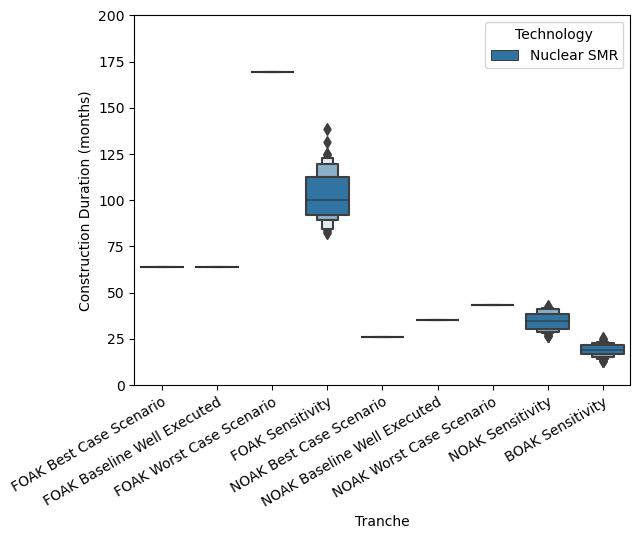

In [11]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Construction Duration",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK Best Case Scenario",
        "FOAK Baseline Well Executed",
        "FOAK Worst Case Scenario",
        "FOAK Sensitivity",
        "NOAK Best Case Scenario",
        "NOAK Baseline Well Executed",
        "NOAK Worst Case Scenario",
        "NOAK Sensitivity",
        "BOAK Sensitivity"
        ]
    )
g.set(ylabel="Construction Duration (months)",
     ylim=(0,200))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK Best Case Scenario'),
 Text(1, 0, 'FOAK Baseline Well Executed'),
 Text(2, 0, 'FOAK Worst Case Scenario'),
 Text(3, 0, 'FOAK Sensitivity'),
 Text(4, 0, 'NOAK Best Case Scenario'),
 Text(5, 0, 'NOAK Baseline Well Executed'),
 Text(6, 0, 'NOAK Worst Case Scenario'),
 Text(7, 0, 'NOAK Sensitivity'),
 Text(8, 0, 'BOAK Sensitivity')]

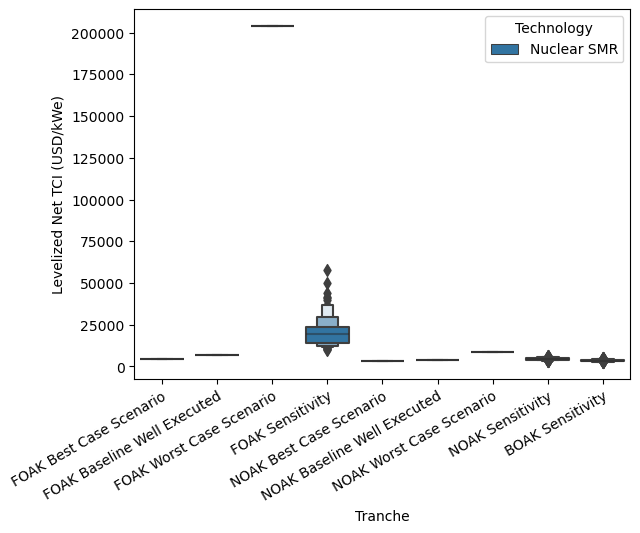

In [12]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Levelized Net TCI",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK Best Case Scenario",
        "FOAK Baseline Well Executed",
        "FOAK Worst Case Scenario",
        "FOAK Sensitivity",
        "NOAK Best Case Scenario",
        "NOAK Baseline Well Executed",
        "NOAK Worst Case Scenario",
        "NOAK Sensitivity",
        "BOAK Sensitivity"
        ]
    )
g.set(ylabel="Levelized Net TCI (USD/kWe)")
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK Best Case Scenario'),
 Text(1, 0, 'FOAK Baseline Well Executed'),
 Text(2, 0, 'FOAK Worst Case Scenario'),
 Text(3, 0, 'FOAK Sensitivity'),
 Text(4, 0, 'NOAK Best Case Scenario'),
 Text(5, 0, 'NOAK Baseline Well Executed'),
 Text(6, 0, 'NOAK Worst Case Scenario'),
 Text(7, 0, 'NOAK Sensitivity'),
 Text(8, 0, 'BOAK Sensitivity')]

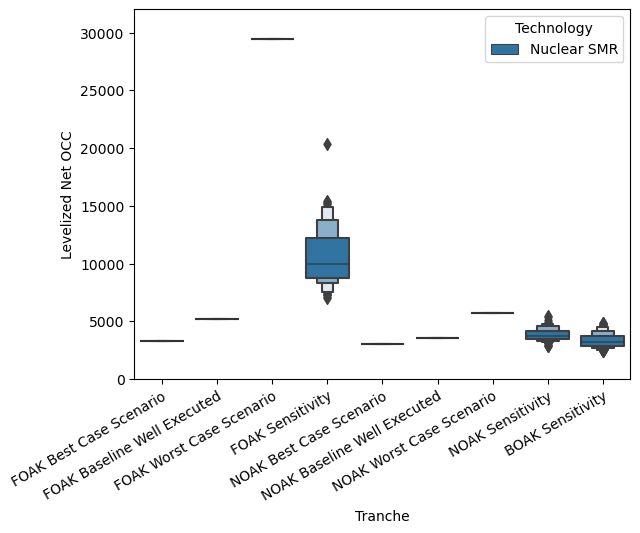

In [13]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Levelized Net OCC",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK Best Case Scenario",
        "FOAK Baseline Well Executed",
        "FOAK Worst Case Scenario",
        "FOAK Sensitivity",
        "NOAK Best Case Scenario",
        "NOAK Baseline Well Executed",
        "NOAK Worst Case Scenario",
        "NOAK Sensitivity",
        "BOAK Sensitivity"
        ]
    )
g.set(ylabel="Levelized Net OCC",
     ylim=(0,32000))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK Best Case Scenario'),
 Text(1, 0, 'FOAK Baseline Well Executed'),
 Text(2, 0, 'FOAK Worst Case Scenario'),
 Text(3, 0, 'FOAK Sensitivity'),
 Text(4, 0, 'NOAK Best Case Scenario'),
 Text(5, 0, 'NOAK Baseline Well Executed'),
 Text(6, 0, 'NOAK Worst Case Scenario'),
 Text(7, 0, 'NOAK Sensitivity'),
 Text(8, 0, 'BOAK Sensitivity')]

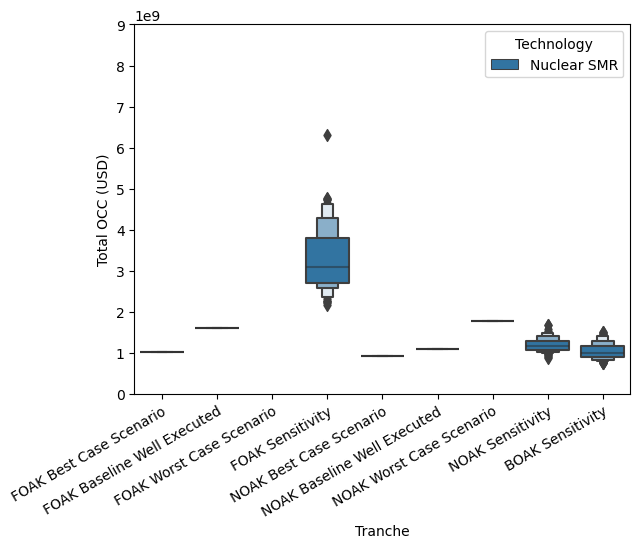

In [14]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Total OCC",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK Best Case Scenario",
        "FOAK Baseline Well Executed",
        "FOAK Worst Case Scenario",
        "FOAK Sensitivity",
        "NOAK Best Case Scenario",
        "NOAK Baseline Well Executed",
        "NOAK Worst Case Scenario",
        "NOAK Sensitivity",
        "BOAK Sensitivity"
        ]
    )
g.set(ylabel="Total OCC (USD)", ylim=(0,9e9))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()